In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("manonstr/tipe-webscraping")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'tipe-webscraping' dataset.
Path to dataset files: /kaggle/input/tipe-webscraping
Contents of base_path (/kaggle/input):
['tipe-webscraping']
Contents of path (/kaggle/input/tipe-webscraping):
['1024+']


Checking for image folders in: /kaggle/input/tipe-webscraping/1024+
Contents of /kaggle/input/tipe-webscraping/1024+: ['entrainement', 'test']
Searching for images in: /kaggle/input/tipe-webscraping/1024+/entrainement
Searching for images in: /kaggle/input/tipe-webscraping/1024+/test

Found 7190 image files in total. Displaying a few samples:


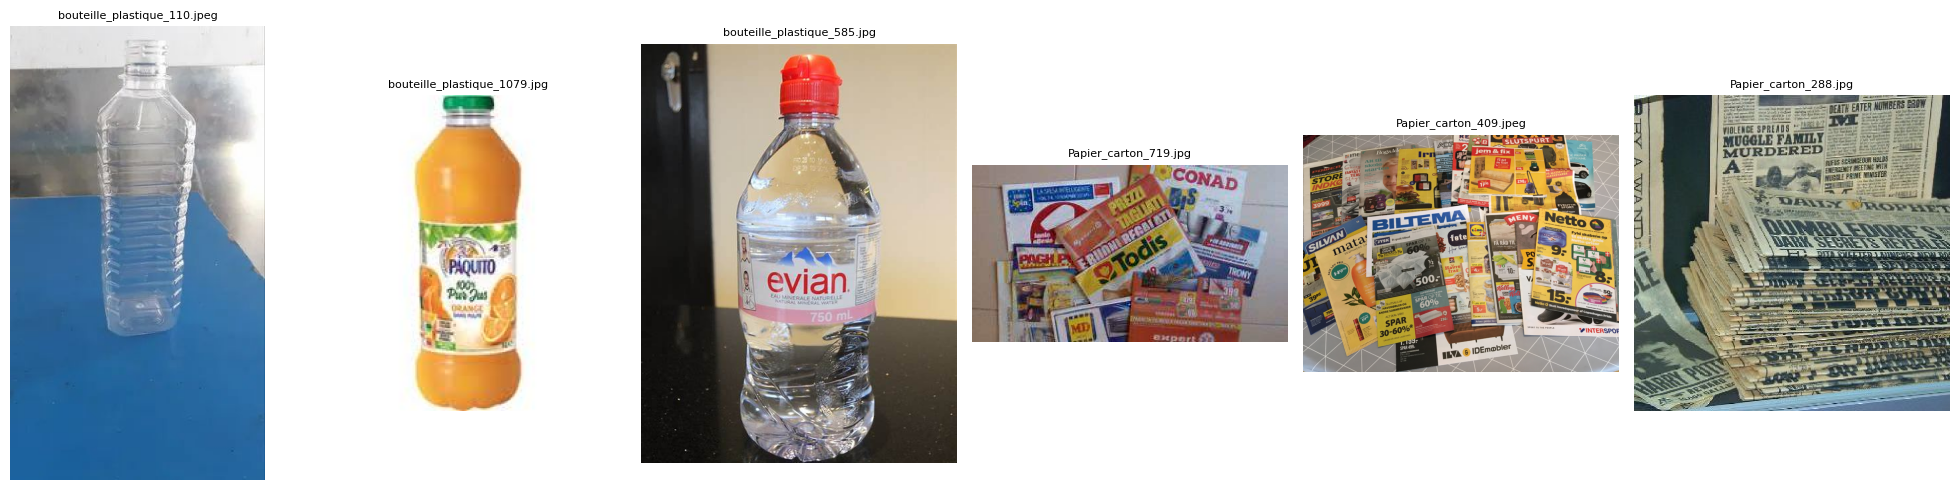

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define the base directory where images are expected (inside '1024+')
image_root_dir = os.path.join(path, '1024+')

print(f"Checking for image folders in: {image_root_dir}")
if not os.path.exists(image_root_dir):
    print(f"Error: Directory '{image_root_dir}' not found. Please ensure the dataset structure is as expected.")
else:
    print(f"Contents of {image_root_dir}: {os.listdir(image_root_dir)}")

    # Collect all image files from 'entrainement' and 'test' subfolders
    all_image_paths = []
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')

    subfolders_to_check = ['entrainement', 'test']

    for subfolder_name in subfolders_to_check:
        current_search_path = os.path.join(image_root_dir, subfolder_name)
        if os.path.isdir(current_search_path):
            print(f"Searching for images in: {current_search_path}")
            for root, dirs, files in os.walk(current_search_path):
                for file in files:
                    if file.lower().endswith(image_extensions):
                        all_image_paths.append(os.path.join(root, file))
        else:
            print(f"Warning: '{subfolder_name}' directory not found at {current_search_path}")

    if all_image_paths:
        print(f"\nFound {len(all_image_paths)} image files in total. Displaying a few samples:")
        # Select a few distinct samples to display (e.g., from beginning and middle)
        samples_to_display = all_image_paths[:min(len(all_image_paths), 3)]
        if len(all_image_paths) > 3:
            samples_to_display.extend(all_image_paths[len(all_image_paths)//2 : min(len(all_image_paths)//2 + 3, len(all_image_paths))])
        samples_to_display = list(dict.fromkeys(samples_to_display)) # Remove duplicates while preserving order
        samples_to_display = samples_to_display[:min(len(samples_to_display), 6)] # Ensure max 6 samples

        if samples_to_display:
            fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
            if len(samples_to_display) == 1:
                axes = [axes] # Make it iterable for consistency

            for i, img_path in enumerate(samples_to_display):
                try:
                    img = Image.open(img_path)
                    axes[i].imshow(img)
                    axes[i].set_title(os.path.basename(img_path), fontsize=8)
                    axes[i].axis('off')
                except Exception as e:
                    axes[i].set_title(f"Error loading {os.path.basename(img_path)}", fontsize=8)
                    axes[i].axis('off')
                    print(f"Error loading image {img_path}: {e}")
            plt.tight_layout()
            plt.show()
        else:
            print("No unique image samples selected for display.")
    else:
        print("\nNo common image files (png, jpg, jpeg, gif, bmp) found in the specified 'entrainement' or 'test' directories.")

## 1. Check GPU Activity
First, let's check if a GPU is available and set the device accordingly. This is crucial for efficient deep learning model training.

In [ ]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("GPU not available, using CPU.")

GPU is available: Tesla T4


## 2. Prepare Dataset and DataLoader
We need to organize the image paths collected earlier into a structured dataset for training and validation. This involves extracting labels from the directory structure, applying transformations, and creating DataLoaders.

In [ ]:
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os

class CustomImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# Assuming labels are the immediate subfolder names within 'entrainement'/'test'
# Example: /.../1024+/entrainement/class_A/image.jpg -> label 'class_A'

def get_image_paths_and_labels(base_dir):
    image_paths = []
    labels = []
    class_to_idx = {}
    idx_to_class = []
    current_label_idx = 0

    for root, dirs, files in os.walk(base_dir):
        if root == base_dir:
            # Skip the immediate 'entrainement' or 'test' directory itself
            continue

        # The label is the name of the immediate parent directory that is not base_dir
        relative_path = os.path.relpath(root, base_dir)
        label_name = relative_path.split(os.sep)[0]

        if label_name not in class_to_idx:
            class_to_idx[label_name] = current_label_idx
            idx_to_class.append(label_name)
            current_label_idx += 1

        for file in files:
            if file.lower().endswith(image_extensions):
                image_paths.append(os.path.join(root, file))
                labels.append(class_to_idx[label_name])
    return image_paths, labels, class_to_idx, idx_to_class

entrainement_dir = os.path.join(image_root_dir, 'entrainement')
test_dir = os.path.join(image_root_dir, 'test')

print(f"Processing training images in: {entrainement_dir}")
train_image_paths, train_labels, class_to_idx, idx_to_class = get_image_paths_and_labels(entrainement_dir)

print(f"Processing test images in: {test_dir}")
test_image_paths, test_labels, _, _ = get_image_paths_and_labels(test_dir)

num_classes = len(class_to_idx)
print(f"Detected {num_classes} classes: {idx_to_class}")
print(f"Found {len(train_image_paths)} training images and {len(test_image_paths)} test images.")

# Define transformations
image_size = 224 # AlexNet expects 224x224 input
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Create datasets
train_dataset = CustomImageDataset(train_image_paths, train_labels, transform=transform)
test_dataset = CustomImageDataset(test_image_paths, test_labels, transform=transform)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train DataLoader created with {len(train_loader)} batches.")
print(f"Test DataLoader created with {len(test_loader)} batches.")

Processing training images in: /kaggle/input/tipe-webscraping/1024+/entrainement
Processing test images in: /kaggle/input/tipe-webscraping/1024+/test
Detected 6 classes: ['Bouteille_plastique', 'Emballage_metallique', 'Papier_Carton', 'Brique_en_carton', 'Verre', 'Ordure_m�nag�re']
Found 7033 training images and 157 test images.
Train DataLoader created with 220 batches.
Test DataLoader created with 5 batches.


## 3. Build AlexNet Model
We will use a pre-trained AlexNet model from `torchvision.models` and adapt its final layer to match the number of classes in our dataset.

In [ ]:
import torch.nn as nn
import torchvision.models as models

# Load pre-trained AlexNet model
alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

# Modify the classifier for our number of classes
alexnet.classifier[6] = nn.Linear(alexnet.classifier[6].in_features, num_classes)

alexnet = alexnet.to(device)

print("AlexNet model loaded and modified:")
print(alexnet)

AlexNet model loaded and modified:
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=92

## 4. Train the Model
Now, let's define the loss function, optimizer, and run the training loop for our AlexNet model.

In [ ]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(alexnet.parameters(), lr=0.001)

# Training loop
num_epochs = 10 # You can adjust the number of epochs

train_losses = []
train_accuracies = []

print("Starting model training...")
for epoch in range(num_epochs):
    alexnet.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = alexnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct_predictions / total_predictions
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

print("Training complete.")

Starting model training...
Epoch 1/10, Loss: 1.8069, Accuracy: 0.2026
Epoch 2/10, Loss: 1.7864, Accuracy: 0.2039
Epoch 3/10, Loss: 1.7865, Accuracy: 0.2053
Epoch 4/10, Loss: 1.7863, Accuracy: 0.2046
Epoch 5/10, Loss: 1.7866, Accuracy: 0.2032
Epoch 6/10, Loss: 1.7870, Accuracy: 0.2019
Epoch 7/10, Loss: 1.7865, Accuracy: 0.2008
Epoch 8/10, Loss: 1.7856, Accuracy: 0.2050
Epoch 9/10, Loss: 1.7859, Accuracy: 0.2036
Epoch 10/10, Loss: 1.7858, Accuracy: 0.2047
Training complete.


## 5. Summarize Training Results
Let's evaluate the model on the test set and print the overall training performance.

In [ ]:
alexnet.eval()
val_correct_predictions = 0
val_total_predictions = 0
val_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = alexnet(inputs)
        loss = criterion(outputs, labels)
        val_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        val_total_predictions += labels.size(0)
        val_correct_predictions += (predicted == labels).sum().item()

final_val_loss = val_loss / len(test_loader)
final_val_accuracy = val_correct_predictions / val_total_predictions

print(f"\n--- Final Training Summary ---")
print(f"Training Epochs: {num_epochs}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Training Accuracy: {train_accuracies[-1]:.4f}")
print(f"Validation Loss: {final_val_loss:.4f}")
print(f"Validation Accuracy: {final_val_accuracy:.4f}")


--- Final Training Summary ---
Training Epochs: 10
Final Training Loss: 1.7858
Final Training Accuracy: 0.2047
Validation Loss: 1.7837
Validation Accuracy: 0.2229


## 6. Visualize Training Charts
Visualize the training loss and accuracy over the epochs to understand the model's learning progress.

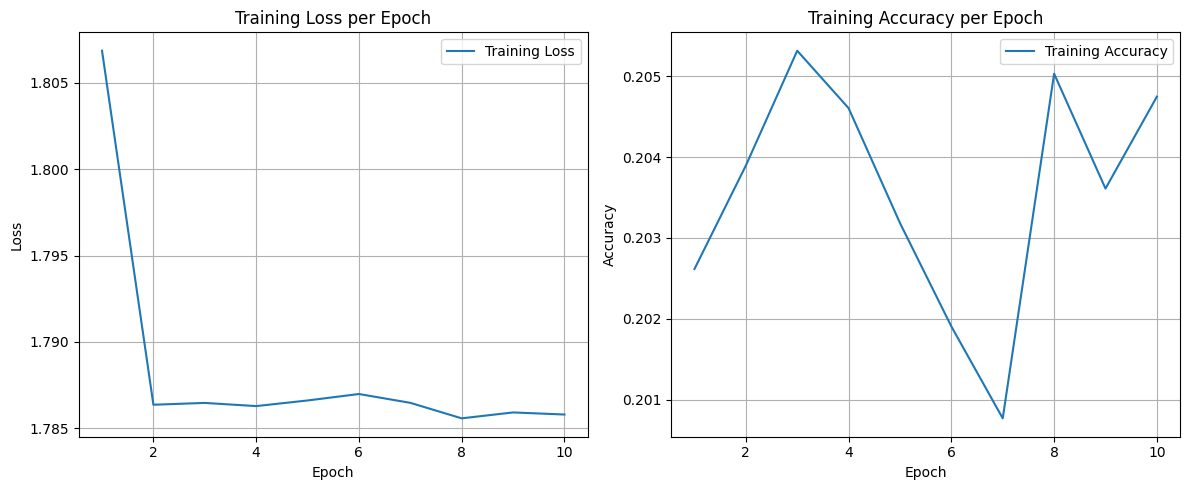

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Plot training loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Plot training accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.title('Training Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()